# Normalize, select, aggregate

Plates differ in imaging day, reagent lot and microscope state, and a CellProfiler run gives a few thousand
features, most of them redundant. This page puts the cells of a JUMP plate on the scale of its own controls and
aggregates them to wells, then reduces the features of a whole screen to the informative ones.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

cells = mt.ds.jump_cells()

## Normalization

Plates differ in imaging day, reagent lot and microscope state. The standard fix is to express
every cell relative to the negative controls on its own plate, which is what
`reference="negcon"` together with `by="Metadata_Plate"` does.

The default method, `mad_robustize`, subtracts the control median and divides by a robust
spread, so a few extreme cells do not set the scale.

In [2]:
mt.pp.normalize(cells, method="mad_robustize", by="Metadata_Plate", reference="negcon", keep_raw=True)

controls = cells[cells.obs["Metadata_Control"].to_numpy()]
np.round(np.nanmedian(np.asarray(controls.X), axis=0)[:5], 6)

<path>:1: UserWarning: 285 of 5839 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(cells, method="mad_robustize", by="Metadata_Plate", reference="negcon", keep_raw=True)


array([0., 0., 0., 0., 0.], dtype=float32)

The controls now sit at zero on every plate by construction. `keep_raw=True` kept the
original values in `layers["raw"]` for the before-and-after plot. It is off by default
because the extra layer doubles memory and the original is already on disk.

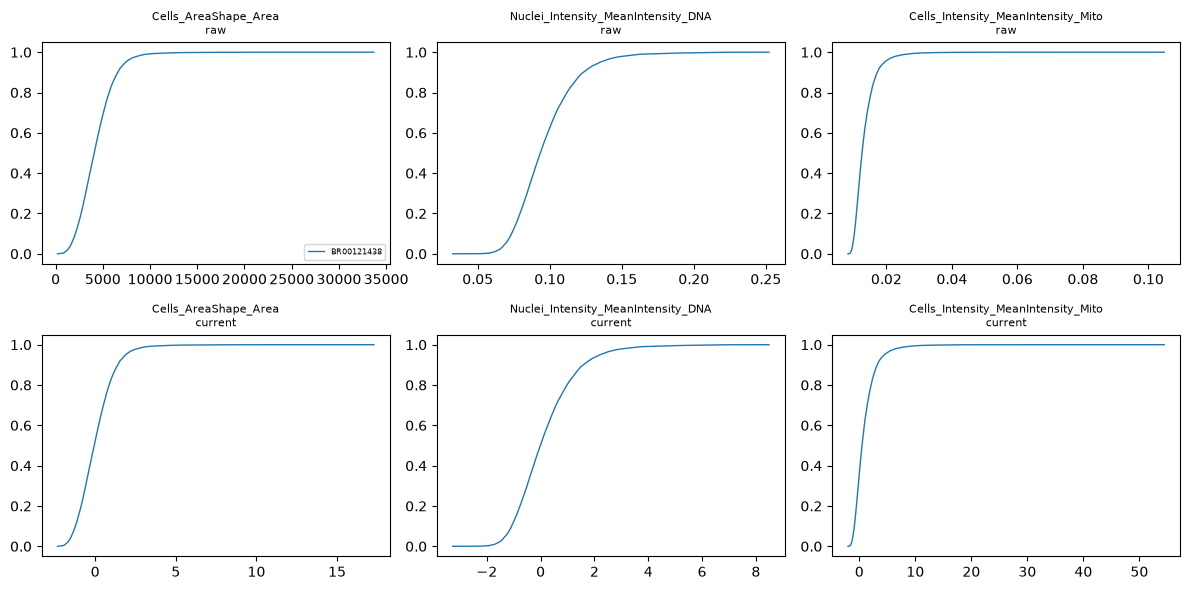

In [3]:
mt.pl.feature_distributions(
    cells, features=["Cells_AreaShape_Area", "Nuclei_Intensity_MeanIntensity_DNA", "Cells_Intensity_MeanIntensity_Mito"]
)
plt.show()

### Features normalization cannot scale

`normalize` warned about features in `var["degenerate_scale"]`. They have no spread among the control cells of
some plate, so `mad_robustize` divides them by `epsilon = 1e-18` instead of by zero, as pycytominer
{cite:p}`Serrano_2025` does, and multiplies them by up to 1e18.

In [4]:
{"flagged degenerate_scale": int(cells.var["degenerate_scale"].sum()), "of": cells.n_vars}

{'flagged degenerate_scale': 285, 'of': 5839}

A variance threshold does not catch a feature that varies across the plate and is constant among the control
wells: it measures variance across all wells, keeps that feature, and the feature then dominates every distance
computed afterwards. The flag catches it. {func}`~mantispy.pp.feature_select` drops flagged features first by
default and judges the rest without them. Anything that reads the object before selection needs them gone by
hand:

```python
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
```

## Aggregating to wells

Each well's profile is the median across its cells. The median is used instead of the mean so
that a few extreme cells do not move the profile.

In [5]:
wells = mt.tl.aggregate(cells, by=("Metadata_Plate", "Metadata_Well"), func="median")
wells

AnnData object with n_obs × n_vars = 24 × 5839
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_BinningX', 'Metadata_BinningY', 'Metadata_ChannelID', 'Metadata_ChannelName', 'Metadata_Col', 'Metadata_ExposureTime', 'Metadata_ImageResolutionX', 'Metadata_ImageResolutionY', 'Metadata_ImageSizeX', 'Metadata_ImageSizeY', 'Metadata_MainEmissionWavelength', 'Metadata_MainExcitationWavelength', 'Metadata_MaxIntensity', 'Metadata_ObjectiveMagnification', 'Metadata_ObjectiveNA', 'Metadata_PlaneID', 'Metadata_PositionZ', 'Metadata_Row', 'Metadata_Source', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'selected', 'degenerate_scale'
    uns: 'mantispy'
    layers: None (.X)

The result records its provenance and keeps every metadata column that is constant within a
well. Columns that vary within a well, such as a per-cell measurement, are dropped because
they have no single value per well.

In [6]:
wells.uns["mantispy"]["aggregated_from"]

{'by': ['Metadata_Plate', 'Metadata_Well'],
 'func': 'median',
 'n_obs': 13578,
 'min_cells': 10}

`Metadata_CellCount` is added as well. Cell count is a common confounder, and `mt.pp.regress_out` can remove its
influence later.

## Feature selection

Most of a CellProfiler run's features are redundant. `AreaShape_Area` and `AreaShape_Perimeter` carry much the
same information, and so does a texture feature at scale 3 and the same texture at scale 5. Others are constant,
or blow up because they are ratios with a near-zero denominator. mantispy reproduces pycytominer's operations
{cite:p}`Serrano_2025`, verified feature by feature, because published pipelines depend on their precise behavior.

Selection needs a screen rather than one plate's 24 wells. `pki` is the JUMP pilot's kinase inhibitors: eight
plates, 3,072 wells {cite:p}`Chandrasekaran_2023`.

In [7]:
screen = mt.ds.pki()
mt.pp.normalize(screen, method="mad_robustize", by="Metadata_Plate", reference="negcon")
screen

<path>:2: UserWarning: 133 of 5839 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(screen, method="mad_robustize", by="Metadata_Plate", reference="negcon")


AnnData object with n_obs × n_vars = 3072 × 5839
    obs: 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale'
    uns: 'mantispy'
    layers: None (.X)

## The operations

Each operation tests one criterion, and `feature_select` combines them. It does not drop
anything: it writes a boolean column to `var`, and only `subset_features` changes the shape,
so you can inspect what would be removed first.

| operation | drops a feature when |
| --- | --- |
| `drop_degenerate` | `normalize` could not scale it and flagged it in `var["degenerate_scale"]` |
| `variance_threshold` | its variance is below `min_variance` |
| `frequency_threshold` | one value dominates it, or it takes very few distinct values |
| `correlation_threshold` | it is highly correlated with another feature |
| `drop_na_columns` | too much of it is missing |
| `blocklist` | it is on the CellProfiler blocklist of known-unreliable features |
| `drop_outliers` | its magnitude has blown up |
| `noise_removal` | it varies too much between replicates of the same perturbation |

Two of these are easy to get wrong.

`variance_threshold` is a plain variance cut. The frequency-and-uniqueness rule often
described under that name is a separate operation, `frequency_threshold`, and its two
criteria combine with OR.

`correlation_threshold` uses the signed correlation, not the absolute value, so two
features correlated at −1.0 are both kept. pycytominer does the same, and mantispy matches
it.

In [8]:
for operation in ("drop_degenerate", "variance_threshold", "correlation_threshold", "drop_na_columns", "blocklist"):
    trial = screen.copy()
    mt.pp.feature_select(trial, operations=(operation,))
    print(f"{operation:24s} keeps {int(trial.var['selected'].sum()):5d} of {trial.n_vars}")

drop_degenerate          keeps  5706 of 5839
variance_threshold       keeps  5828 of 5839


correlation_threshold    keeps   928 of 5839
drop_na_columns          keeps  5839 of 5839
blocklist                keeps  5784 of 5839


Each operation is judged on its own here. `correlation_threshold` does the most, because most of a CellProfiler
run is near-duplicates of other features.

## Running the default pipeline

The default runs five of the eight operations: `drop_degenerate`, which runs first, and pycytominer's own default
of four. `frequency_threshold` and `drop_outliers` are off because both can remove an informative feature on a
screen with few conditions, and `noise_removal` is off because it needs replicate structure, which not every
object has.

In [9]:
mt.pp.feature_select(screen)
screen.uns["mantispy"]["feature_select"]

{'drop_degenerate': 133,
 'variance_threshold': 0,
 'correlation_threshold': 4836,
 'drop_na_columns': 0,
 'blocklist': 55}

### Before and after

The correlation heatmap is ordered by feature group, with a line at each group boundary. Here it is for the shape
measurements of the whole cell, before selection and after. Blocks along the diagonal are features that measure
nearly the same thing.

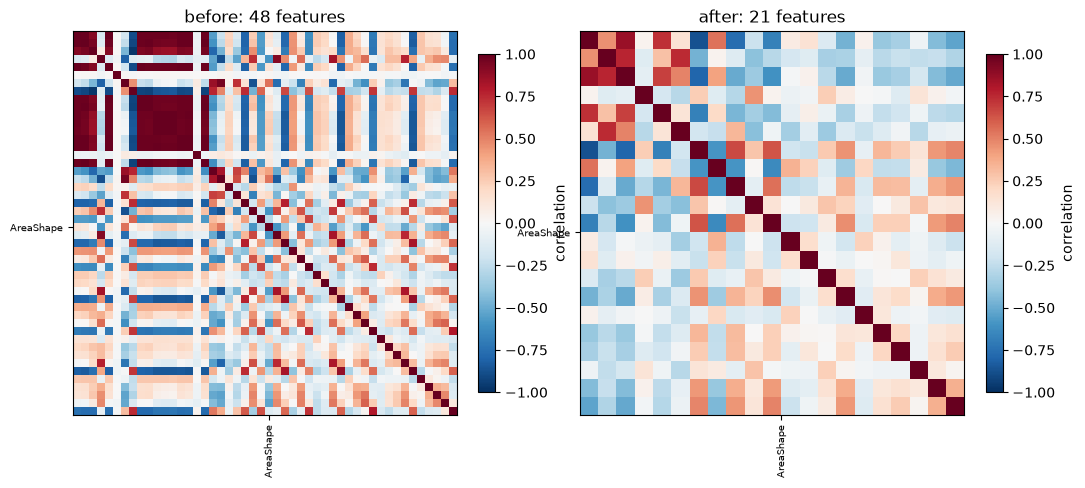

In [10]:
shape = ((screen.var["object"] == "Cells") & (screen.var["feature_group"] == "AreaShape")).to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mt.pl.feature_correlation(screen[:, shape].copy(), key=None, ax=axes[0])
axes[0].set_title(f"before: {int(shape.sum())} features")
kept = shape & screen.var["selected"].to_numpy()
mt.pl.feature_correlation(screen[:, kept].copy(), key=None, ax=axes[1])
axes[1].set_title(f"after: {int(kept.sum())} features")
plt.show()

Of the 48 shape measurements of the whole cell, 21 survive. The large block of features that move together
collapses to a few, and what remains correlates below the cutoff. Strongly negative pairs survive, because the cut
uses the signed correlation, as pycytominer's does. `pl.feature_groups` shows which feature families lost
features to selection.

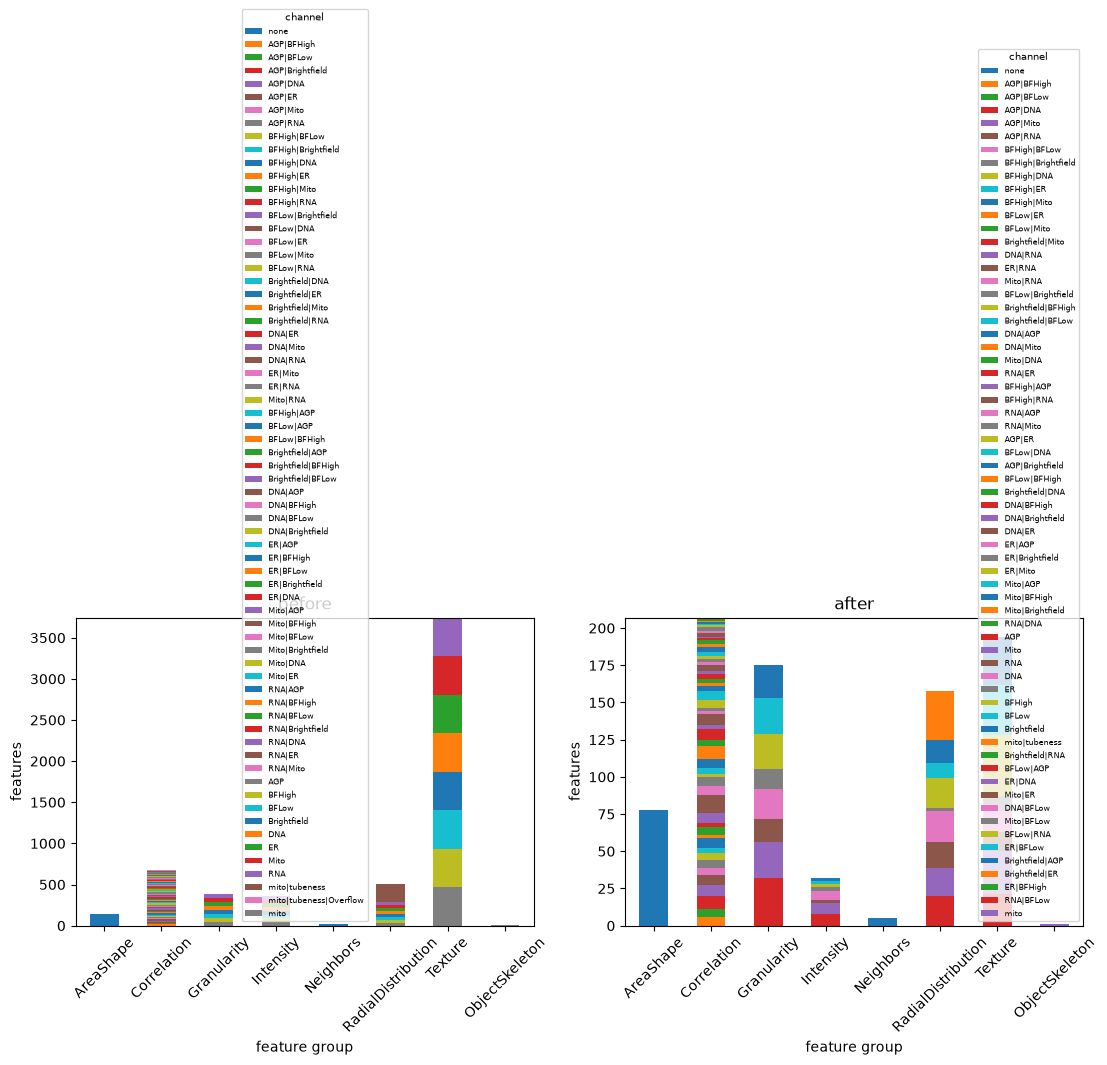

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
mt.pl.feature_groups(screen, ax=axes[0])
axes[0].set_title("before")
mt.pl.feature_groups(screen, key="selected", ax=axes[1])
axes[1].set_title("after")
plt.show()

### The blocklist

The default blocklist is pycytominer's, copied unchanged with its source recorded in the file. It lists features
known to be unreliable: twenty Manders and twenty rank-weighted colocalization coefficients, plus the three
highest nuclear granularity bands in each channel. `MeasureColocalization` writes Manders, RWC and Costes
coefficients, and only the first two are on the list.

In [12]:
from mantispy._core.features import load_blocklist

blocked = load_blocklist()
{"on the list": len(blocked), "in this screen": int(screen.var_names.isin(blocked).sum()), "examples": blocked[:3]}

{'on the list': 55,
 'in this screen': 55,
 'examples': ['Nuclei_Correlation_Manders_AGP_DNA',
  'Nuclei_Correlation_Manders_AGP_ER',
  'Nuclei_Correlation_Manders_AGP_Mito']}

## Scaling correlation to large screens

`correlation_threshold` compares every pair of features, so its cost grows with the square of the feature count;
on a screen with tens of thousands of features the exact pass takes minutes.

mantispy keeps the exact pass as the default, matching pycytominer {cite:p}`Serrano_2025`. Passing `corr_window`
switches to a faster two-pass approximation: pass one sorts features by name (a CellProfiler family sorts
together) and prunes redundancy only within a sliding window, which is cheap and whittles the list down; pass two
runs the exact all-pairs correlation on the survivors, a much smaller set, so it catches the cross-family
redundancy the windows could not see while its quadratic cost stays small. A window of 500 is a good default.

Be clear about the deviation from the standard: the fast pass does not reproduce the exact pass feature for
feature. Correlated features are near-duplicates, so which member survives is close to arbitrary, and the fast
pass keeps a different set. What matters is whether the reduced space keeps the same information and the same
biology. The next cells measure exactly that, across strategies.

In [13]:
import time

import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_predict

# Normalize a copy so the downstream mAP is meaningful, then compare selection strategies on it.
base = screen.copy()
mt.pp.normalize(base, method="mad_robustize", by="Metadata_Plate")
matrix = np.nan_to_num(np.asarray(base.X, dtype=np.float64))
matrix = (matrix - matrix.mean(0)) / (matrix.std(0) + 1e-9)
rng = np.random.default_rng(0)


def reconstruct_r2(target, predictors, n=30):
    """Cross-validated R2 predicting each target feature from the predictor feature set."""
    # cross-validated R2 predicting each target feature from the predictor set: is the information kept
    cols = rng.choice(target, size=min(n, len(target)), replace=False)
    block = matrix[:, predictors]
    scores = []
    for c in cols:
        y = matrix[:, c]
        tot = ((y - y.mean()) ** 2).sum()
        if tot == 0:
            scores.append(1.0)
            continue
        pred = cross_val_predict(RidgeCV(), block, y, cv=5)
        scores.append(1.0 - ((y - pred) ** 2).sum() / tot)
    return float(np.mean(scores))


def select(**kwargs):
    """Run feature_select with these kwargs; return the boolean selection mask and the runtime."""
    adata = base.copy()
    start = time.perf_counter()
    mt.pp.feature_select(adata, operations=("drop_degenerate", "correlation_threshold"), **kwargs)
    return adata.var["selected"].to_numpy(dtype=bool), time.perf_counter() - start


def replicate_map(mask):
    """Mean replicate-retrieval mAP on the subset of features flagged by mask."""
    # downstream biology: do a compound's replicate wells retrieve each other in the reduced space
    adata = base[:, mask].copy()
    mt.tl.map(adata, mode="replicability", null_size=1000, reference=None, seed=0)
    return float(adata.obs["map"].mean())


strategies = {"exact": {}, "fast (window 500)": {"corr_window": 500}, "fast (window 1500)": {"corr_window": 1500}}
masks = {name: select(**kw) for name, kw in strategies.items()}
exact_mask = masks["exact"][0]
exact_idx = np.flatnonzero(exact_mask)

rows = []
for name, (mask, seconds) in masks.items():
    idx = np.flatnonzero(mask)
    rows.append(
        {
            "features kept": int(mask.sum()),
            "time (s)": round(seconds, 1),
            "overlap with exact (Jaccard)": round((exact_mask & mask).sum() / (exact_mask | mask).sum(), 3),
            "information kept (R2 vs exact)": 1.0 if name == "exact" else round(reconstruct_r2(exact_idx, idx), 3),
            "replicate mAP": round(replicate_map(mask), 3),
        }
    )
pd.DataFrame(rows, index=list(strategies))

<path>:10: UserWarning: 133 of 5839 features have no spread in at least one group of 'Metadata_Plate'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(base, method="mad_robustize", by="Metadata_Plate")


,features kept,time (s),overlap with exact (Jaccard),information kept (R2 vs exact),replicate mAP
exact,853,2.8,1.000,1.000,0.419
fast (window 500),972,0.5,0.548,0.995,0.421
fast (window 1500),988,0.8,0.551,0.991,0.420


Interpret the table you expect: the fast selections overlap the exact one only about half at the feature level
(this is the deviation from pycytominer, and it is real), yet they reconstruct the exact features at an R2 near 1
and reach the same replicate mAP. Different features, same information, same biology. Window size trades a little
speed for a slightly larger, still-equivalent set.

In [14]:
from anndata import AnnData

rng = np.random.default_rng(0)
n_cells, n_features, n_drivers = 2000, 20_000, 1500
drivers = rng.standard_normal((n_cells, n_drivers), dtype=np.float32)
assign = np.sort(rng.integers(0, n_drivers, size=n_features))
X = drivers[:, assign] + rng.standard_normal((n_cells, n_features), dtype=np.float32) * 0.05
names = [f"Cells_Texture_Driver{assign[i]:05d}_{i:06d}" for i in range(n_features)]
big = AnnData(X, var=pd.DataFrame(index=names))


def timed(**kwargs):
    """Run feature_select on the synthetic screen; return the runtime and the features kept."""
    adata = big.copy()
    start = time.perf_counter()
    mt.pp.feature_select(adata, operations=("correlation_threshold",), **kwargs)
    return time.perf_counter() - start, int(adata.var["selected"].sum())


exact_time, exact_kept = timed()
fast_time, fast_kept = timed(corr_window=500)
{
    "features": n_features,
    "exact": f"{exact_time:.1f}s, {exact_kept} kept",
    "fast (window 500)": f"{fast_time:.1f}s, {fast_kept} kept",
    "speedup": f"{exact_time / fast_time:.1f}x",
}

{'features': 20000,
 'exact': '16.8s, 1500 kept',
 'fast (window 500)': '1.3s, 1500 kept',
 'speedup': '13.3x'}

Guidance: use the exact default for faithful pycytominer parity, and reach for `corr_window=500` when a screen has
many thousands of features and the correlation step dominates. The saving grows with the feature count, and the
reduced space carries the same information and the same replicate signal.

## Looking at the plates

Plate layout artifacts are easiest to see on a plate map. `pl.plate` draws any feature or `obs` column; here, how
many cells each well of the eight plates held.

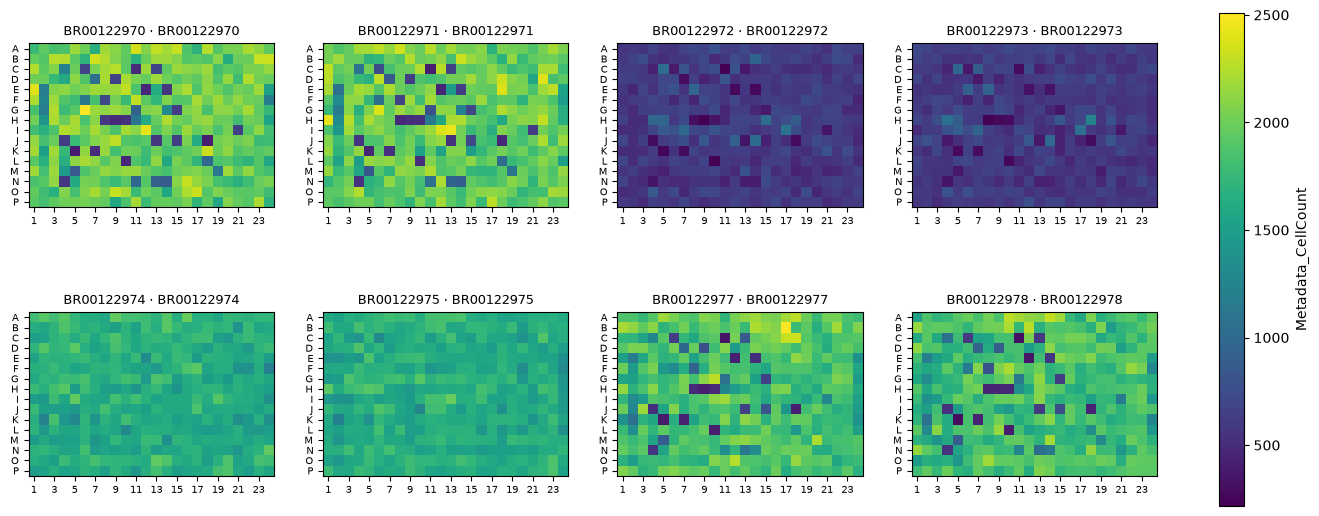

In [15]:
mt.pl.plate(screen, color="Metadata_CellCount", groupby="Metadata_Plate", ncols=4)
plt.show()

## Handing off

`get.to_dataframe` returns the flat, metadata-first table that pycytominer {cite:p}`Serrano_2025`, cytominer-eval
and most published scripts expect.

In [16]:
frame = mt.get.to_dataframe(mt.pp.subset_features(screen))
frame.iloc[:3, :6]

,Metadata_plate_map_name,Metadata_broad_sample,Metadata_mg_per_ml,Metadata_mmoles_per_liter,Metadata_solvent,Metadata_Plate
0,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970
1,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970
2,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970


Next: [Plate artifacts and corrections](artifacts.ipynb).